In [1]:
import os
import sys
from pathlib import Path

ROOT = Path().resolve().parents[2]

os.chdir(ROOT)

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("ROOT:", ROOT)
print("CWD:", Path.cwd())

ROOT: /home/jay/dev/document-type-classification-cv-2
CWD: /home/jay/dev/document-type-classification-cv-2


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
config_path = Path("experiments/template/configs/train.yaml")

experiment_root = config_path.resolve().parents[1]

metrics_path = experiment_root / "outputs" / "metrics.csv"

df = pd.read_csv(metrics_path)

print(df.shape)
df.head()

(1, 9)


,epoch,train_loss,train_accuracy,train_f1_micro,train_f1_macro,valid_loss,valid_accuracy,valid_f1_micro,valid_f1_macro
0,1,3.041111,0.08758,0.08758,0.07764,2.869269,0.121019,0.121019,0.046748


In [4]:
df

,epoch,train_loss,train_accuracy,train_f1_micro,train_f1_macro,valid_loss,valid_accuracy,valid_f1_micro,valid_f1_macro
0,1,3.041111,0.08758,0.08758,0.07764,2.869269,0.121019,0.121019,0.046748


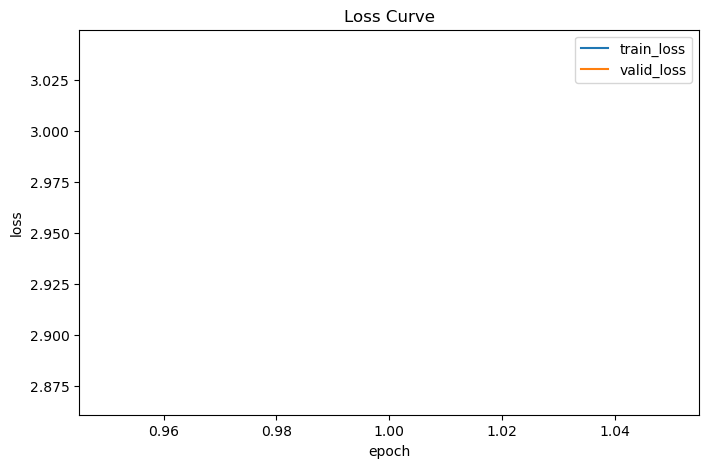

In [5]:
plt.figure(figsize=(8, 5))

plt.plot(df["epoch"], df["train_loss"], label="train_loss")
plt.plot(df["epoch"], df["valid_loss"], label="valid_loss")

plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Loss Curve")
plt.legend()
plt.show()

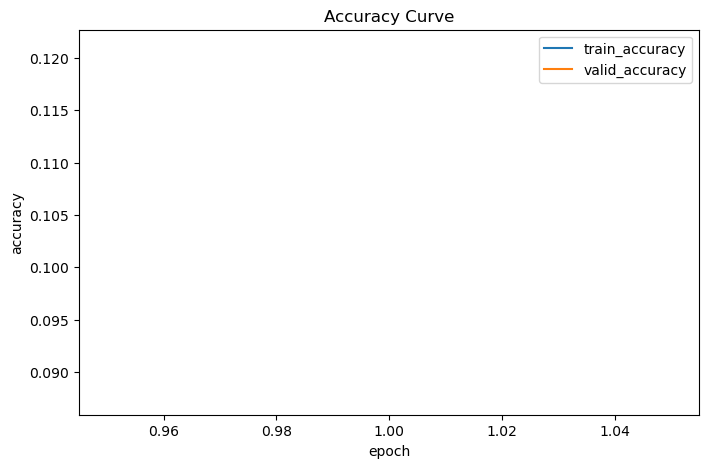

In [7]:
plt.figure(figsize=(8, 5))

plt.plot(df["epoch"], df["train_accuracy"], label="train_accuracy")
plt.plot(df["epoch"], df["valid_accuracy"], label="valid_accuracy")

plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.show()

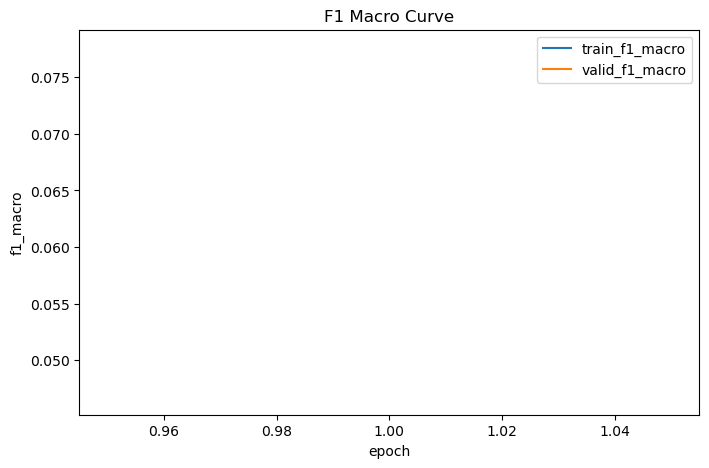

In [8]:
plt.figure(figsize=(8, 5))

plt.plot(df["epoch"], df["train_f1_macro"], label="train_f1_macro")
plt.plot(df["epoch"], df["valid_f1_macro"], label="valid_f1_macro")

plt.xlabel("epoch")
plt.ylabel("f1_macro")
plt.title("F1 Macro Curve")
plt.legend()
plt.show()

In [9]:
best_idx = df["valid_f1_macro"].idxmax()

best_row = df.loc[best_idx]

print("Best Epoch:", best_row["epoch"])
print(best_row)

Best Epoch: 1.0
epoch             1.000000
train_loss        3.041111
train_accuracy    0.087580
train_f1_micro    0.087580
train_f1_macro    0.077640
valid_loss        2.869269
valid_accuracy    0.121019
valid_f1_micro    0.121019
valid_f1_macro    0.046748
Name: 0, dtype: float64


In [ ]:
'''
출력 결과 후 확인해야 될 포인트

1. train vs valid gap (overfitting 여부)
2. f1_macro가 계속 상승하는지
3. valid 성능이 plateau 되는 시점
4. loss 감소 여부
'''

'\n확인 포인트\n\n1. train vs valid gap (overfitting 여부)\n2. f1_macro가 계속 상승하는지\n3. valid 성능이 plateau 되는 시점\n4. loss 감소 여부\n'